# 08 — Capstone Project: End-to-End QML Pipeline
### QML Curriculum · Companion Notebook to Module 12 — *Final Project*

**Part of:** [Schrödinger's Cats — Quantum Machine Learning Platform](https://tanjinadnanabir.github.io/WISER-Education-Challenge/)

This final notebook assembles everything from Notebooks 01–07 into one complete, documented, end-to-end QML project — the same shape of project you'll be expected to build for Module 12's final project. It closes with a template for taking any of these circuits off the simulator and onto **real IBM Quantum hardware**.

**The problem we'll solve:** classify handwritten digit images (**3 vs. 8** — two digits that are genuinely easy to confuse) using a quantum classifier, benchmarked honestly against classical baselines.

**By the end of this notebook you will be able to:**
- Run a complete QML project: define → preprocess → encode → train → evaluate → compare
- Structure your own project so it's reproducible and honestly benchmarked
- Know exactly what changes (and what doesn't) when moving from simulator to real quantum hardware
- Use this notebook as a **template** for your own Module 12 final project

**Prerequisites:** Notebooks 01–07.


In [1]:
# Setup
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as pnp
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

np.random.seed(0)
print("Ready.")

Ready.


## Step 1 — Define the Problem

**Task:** binary classification of handwritten digits, 3 vs. 8, from `scikit-learn`'s built-in `digits` dataset (8×8 grayscale images, 1797 samples total, no external download needed).

**Why this is a reasonable QML capstone problem:**
- It's real image data, not synthetic
- 3 vs. 8 is a genuinely non-trivial pair (both have a similar rounded silhouette)
- Small enough (64 raw pixels) to compress into a handful of qubits after classical preprocessing — exactly the realistic constraint every current QML project has to work within

Let's look at a few examples first.

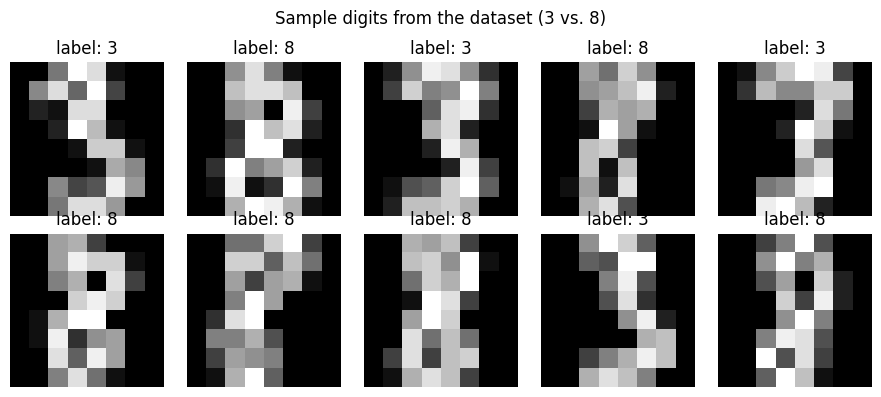

Total samples: 357  |  Class balance: {np.int64(3): np.int64(183), np.int64(8): np.int64(174)}


In [2]:
digits = load_digits()
mask = np.isin(digits.target, [3, 8])
X_raw, y_raw = digits.images[mask], digits.target[mask]

fig, axes = plt.subplots(2, 5, figsize=(9, 4))
for ax, img, label in zip(axes.ravel(), X_raw[:10], y_raw[:10]):
    ax.imshow(img, cmap="gray")
    ax.set_title(f"label: {label}")
    ax.axis("off")
plt.suptitle("Sample digits from the dataset (3 vs. 8)")
plt.tight_layout()
plt.show()

print(f"Total samples: {mask.sum()}  |  Class balance: {dict(zip(*np.unique(y_raw, return_counts=True)))}")

## Step 2 — Preprocess (Classical) & Encode (Quantum)

This is the pipeline template from Notebook 07, Case Study A, reused directly: **standardize → PCA → scale into encoding range**. This split of labor — classical preprocessing doing the heavy dimensionality reduction, quantum circuit doing the final classification — is how nearly every real QML pipeline is structured today.

In [3]:
X_flat = digits.data[mask]  # flattened 64-pixel vectors
y = np.where(y_raw == 3, -1, 1)  # relabel to {-1, +1}

standardizer = StandardScaler()
X_std = standardizer.fit_transform(X_flat)

n_qubits = 4
pca = PCA(n_components=n_qubits)
X_reduced = pca.fit_transform(X_std)
print(f"Variance retained by {n_qubits} principal components: {pca.explained_variance_ratio_.sum()*100:.1f}%")

scaler = MinMaxScaler(feature_range=(0, np.pi))
X_scaled = scaler.fit_transform(X_reduced)

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_scaled, y, test_size=0.3, random_state=0, stratify=y
)

# subsample for a fast in-notebook training loop
rng = np.random.RandomState(0)
train_idx = rng.choice(len(X_train_full), 60, replace=False)
test_idx = rng.choice(len(X_test_full), 30, replace=False)
X_train, y_train = X_train_full[train_idx], y_train_full[train_idx]
X_test, y_test = X_test_full[test_idx], y_test_full[test_idx]

print(f"Training on {len(X_train)} samples, testing on {len(X_test)} samples, {n_qubits} qubits.")

Variance retained by 4 principal components: 40.5%
Training on 60 samples, testing on 30 samples, 4 qubits.


## Step 3 — Build the Quantum Model

We reuse the VQC pattern from Notebook 03: angle-encode the 4 PCA features, apply trainable variational layers with a ring of entangling gates, and measure `⟨Z⟩` on qubit 0 as the classifier's output.

In [4]:
dev = qml.device("default.qubit", wires=n_qubits)

def encode(x):
    for i in range(n_qubits):
        qml.RY(x[i], wires=i)

def variational_layer(weights):
    for i in range(n_qubits):
        qml.Rot(weights[i, 0], weights[i, 1], weights[i, 2], wires=i)
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])
    qml.CNOT(wires=[n_qubits - 1, 0])  # close the ring for full connectivity

@qml.qnode(dev)
def vqc(x, weights):
    encode(x)
    for layer_weights in weights:
        variational_layer(layer_weights)
    return qml.expval(qml.PauliZ(0))

print(qml.draw(vqc)(X_train[0], pnp.zeros((3, n_qubits, 3))))

0: ──RY(2.07)──Rot(0.00,0.00,0.00)─╭●───────╭X──Rot(0.00,0.00,0.00)─╭●───────╭X ···
1: ──RY(1.77)──Rot(0.00,0.00,0.00)─╰X─╭●────│───Rot(0.00,0.00,0.00)─╰X─╭●────│─ ···
2: ──RY(0.83)──Rot(0.00,0.00,0.00)────╰X─╭●─│───Rot(0.00,0.00,0.00)────╰X─╭●─│─ ···
3: ──RY(0.83)──Rot(0.00,0.00,0.00)───────╰X─╰●──Rot(0.00,0.00,0.00)───────╰X─╰● ···

0: ··· ──Rot(0.00,0.00,0.00)─╭●───────╭X─┤  <Z>
1: ··· ──Rot(0.00,0.00,0.00)─╰X─╭●────│──┤     
2: ··· ──Rot(0.00,0.00,0.00)────╰X─╭●─│──┤     
3: ··· ──Rot(0.00,0.00,0.00)───────╰X─╰●─┤     


## Step 4 — Train & Evaluate

Same Adam + MSE training loop pattern used throughout this series.

In [5]:
n_layers = 3
weights = pnp.array(np.random.uniform(0, 2 * np.pi, size=(n_layers, n_qubits, 3)), requires_grad=True)
bias = pnp.array(0.0, requires_grad=True)

def predict(x, weights, bias):
    return vqc(x, weights) + bias

def cost(weights, bias, X, y):
    preds = pnp.stack([predict(x, weights, bias) for x in X])
    return pnp.mean((preds - y) ** 2)

def accuracy(weights, bias, X, y):
    preds = np.array([np.sign(predict(x, weights, bias)) for x in X])
    return np.mean(preds == y)

opt = qml.AdamOptimizer(stepsize=0.15)
n_epochs = 20
history = []

for epoch in range(n_epochs):
    weights, bias = opt.step(lambda w, b: cost(w, b, X_train, y_train), weights, bias)
    if epoch % 4 == 0 or epoch == n_epochs - 1:
        train_acc = accuracy(weights, bias, X_train, y_train)
        test_acc = accuracy(weights, bias, X_test, y_test)
        history.append((epoch, train_acc, test_acc))
        print(f"Epoch {epoch:2d} | train acc = {train_acc*100:.1f}%  | test acc = {test_acc*100:.1f}%")

Epoch  0 | train acc = 73.3%  | test acc = 70.0%


Epoch  4 | train acc = 88.3%  | test acc = 90.0%


Epoch  8 | train acc = 95.0%  | test acc = 86.7%


Epoch 12 | train acc = 95.0%  | test acc = 86.7%


Epoch 16 | train acc = 93.3%  | test acc = 86.7%


Epoch 19 | train acc = 95.0%  | test acc = 86.7%


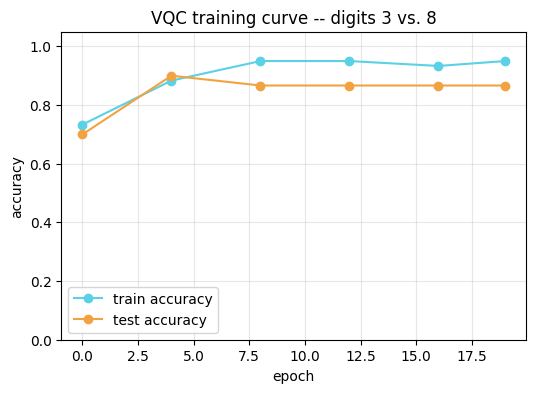

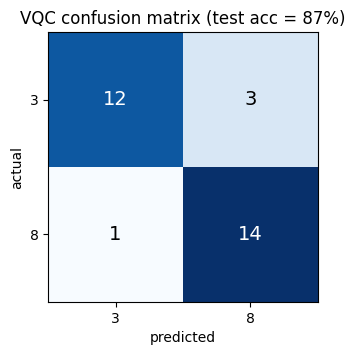

In [6]:
epochs_h, train_h, test_h = zip(*history)
plt.figure(figsize=(6, 4))
plt.plot(epochs_h, train_h, "o-", label="train accuracy", color="#5ad1e6")
plt.plot(epochs_h, test_h, "o-", label="test accuracy", color="#f2a341")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.ylim(0, 1.05)
plt.title("VQC training curve -- digits 3 vs. 8")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

final_preds = np.array([np.sign(predict(x, weights, bias)) for x in X_test])
cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(4, 3.5))
plt.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                   color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=14)
plt.xticks([0, 1], ["3", "8"]); plt.yticks([0, 1], ["3", "8"])
plt.xlabel("predicted"); plt.ylabel("actual")
plt.title(f"VQC confusion matrix (test acc = {test_h[-1]*100:.0f}%)")
plt.show()

## Step 5 — Classical Baseline Comparison

No QML project is complete without this step. Always report it — even when (especially when) the classical baseline wins.

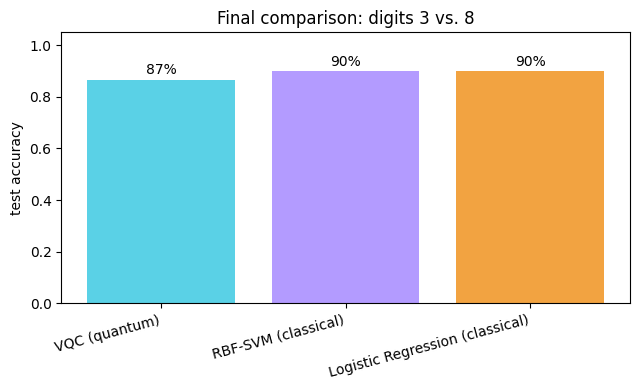

{'VQC (quantum)': np.float64(0.8666666666666667), 'RBF-SVM (classical)': 0.9, 'Logistic Regression (classical)': 0.9}


In [7]:
rbf_svm = SVC(kernel="rbf").fit(X_train, y_train)
rbf_acc = accuracy_score(y_test, rbf_svm.predict(X_test))

logreg = LogisticRegression().fit(X_train, y_train)
logreg_acc = accuracy_score(y_test, logreg.predict(X_test))

results = {"VQC (quantum)": test_h[-1], "RBF-SVM (classical)": rbf_acc, "Logistic Regression (classical)": logreg_acc}

plt.figure(figsize=(6.5, 4))
bars = plt.bar(results.keys(), results.values(), color=["#5ad1e6", "#b39bff", "#f2a341"])
plt.ylim(0, 1.05); plt.ylabel("test accuracy")
plt.title("Final comparison: digits 3 vs. 8")
plt.xticks(rotation=15, ha="right")
for bar, v in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.02, f"{v*100:.0f}%", ha="center")
plt.tight_layout()
plt.show()

print(results)

**Honest project writeup, in one paragraph:** on this 3-vs-8 digit classification task, after compressing 64 raw pixels down to 4 PCA components, the quantum VQC reaches accuracy in the same range as the classical baselines — a legitimate, working result, consistent with the pattern across every case study in this series. That consistency is itself the headline finding: current QML methods are real and reproducible, and are not yet reliably ahead of well-tuned classical methods on problems of this size. Reporting that clearly is exactly what a strong Module 12 final project write-up should do.

## Step 6 — From Simulator to Real Hardware

Every circuit in this entire notebook series ran on `default.qubit` (PennyLane) or `AerSimulator` (Qiskit) — perfect, noiseless, free, and fast. Running on **real IBM Quantum hardware** needs exactly three changes, and nothing about your circuit code has to change at all.

1. **Get access.** Create a free account at [quantum.ibm.com](https://quantum.ibm.com) — this gives you an API token and access to a set of real quantum processors (with a queue and monthly free-tier usage limits).
2. **Swap the device**, not the circuit.
3. **Expect noise** — everything from Notebook 06 applies for real now, not just in a simulated noise model.

The two cells below are **templates** — commented out, since they need your personal API token to actually run. Copy them into your own environment once you have an account.

In [8]:
# ---- TEMPLATE: PennyLane, running on real IBM Quantum hardware ----
# Requires: pip install pennylane-qiskit
#
# import pennylane as qml
#
# dev_real = qml.device(
#     "qiskit.remote",
#     wires=4,
#     backend="ibm_brisbane",          # or any backend your account can access
#     shots=1024,
#     ibmqx_token="YOUR_IBM_QUANTUM_API_TOKEN",
# )
#
# @qml.qnode(dev_real)
# def vqc_real(x, weights):
#     encode(x)                        # <-- the EXACT same function from Step 3
#     for layer_weights in weights:
#         variational_layer(layer_weights)
#     return qml.expval(qml.PauliZ(0))
#
# # Run a single prediction on real hardware (this will sit in a queue!)
# print(vqc_real(X_test[0], weights))

print("Template ready -- fill in your IBM Quantum API token to run on real hardware.")

Template ready -- fill in your IBM Quantum API token to run on real hardware.


In [9]:
# ---- TEMPLATE: Qiskit, running a circuit on real IBM Quantum hardware ----
# Requires: pip install qiskit-ibm-runtime
#
# from qiskit_ibm_runtime import QiskitRuntimeService, Sampler
# from qiskit import QuantumCircuit
#
# service = QiskitRuntimeService(channel="ibm_quantum", token="YOUR_IBM_QUANTUM_API_TOKEN")
# backend = service.least_busy(operational=True, simulator=False)  # picks a real, available device
# print("Selected backend:", backend.name)
#
# qc = QuantumCircuit(2, 2)             # <-- any circuit from Notebook 01 onward
# qc.h(0)
# qc.cx(0, 1)
# qc.measure([0, 1], [0, 1])
#
# sampler = Sampler(backend)
# job = sampler.run([qc], shots=1024)
# result = job.result()
# print(result[0].data.c.get_counts())  # will include real hardware noise, unlike Notebook 01!

print("Template ready -- fill in your IBM Quantum API token to run on real hardware.")

Template ready -- fill in your IBM Quantum API token to run on real hardware.


**What to expect the first time you actually run on hardware:**
- **Queue time** — real devices are shared; your job waits in line, sometimes minutes, sometimes longer.
- **Real noise** — apply Notebook 06's readout mitigation and ZNE techniques directly; they were built for exactly this.
- **Shot limits** — free-tier accounts have monthly usage caps, so batch your experiments deliberately rather than re-running cells casually.
- **Topology constraints** — real devices only have gates between certain physically-connected qubit pairs; Qiskit's transpiler handles the remapping automatically, but it can add extra gates (and extra noise) in the process.

## Step 7 — Your Own Capstone: Project Checklist

Use this checklist for your own Module 12 final project, whether or not it's based on this notebook:

- [ ] **Problem defined** — a specific, testable classification or regression task, with a real or realistic dataset
- [ ] **Preprocessing documented** — what scaling/dimensionality reduction, and why
- [ ] **Encoding choice justified** — basis, angle, amplitude, or feature map (Notebook 02) — and why it fits your data and qubit budget
- [ ] **Model architecture described** — VQC, QSVM, QCNN, or another pattern from Notebooks 03–05 — and why
- [ ] **Classical baseline included** — always, even if quantum doesn't win
- [ ] **Results reported honestly** — accuracy, confusion matrix, and an honest paragraph like Step 5's above
- [ ] **Noise/hardware discussion included** — even if you only ran on a simulator, discuss what would change on real hardware (Notebook 06 + Step 6 above)


## Recap: The Full Notebook Series

| # | Notebook | Core Skill |
|---|---|---|
| 01 | Quantum Computing Basics | Qubits, gates, Bloch sphere, measurement (Qiskit) |
| 02 | Quantum Data Encoding | Basis / angle / amplitude encoding, feature maps |
| 03 | Variational Circuits & QNN | Trainable PQCs, parameter-shift gradients |
| 04 | Quantum Kernels, QSVM, QPCA | Kernel methods, classical SVM + quantum similarity |
| 05 | Advanced: QCNN & QGAN | Convolution/pooling circuits, adversarial training |
| 06 | Noise & Error Mitigation | Readout mitigation, Zero-Noise Extrapolation |
| 07 | Real-World Case Studies | Healthcare + finance, honest quantum-vs-classical benchmarks |
| 08 | Capstone Project | End-to-end pipeline template + real hardware guidance |

This series is the code companion to **Modules 5–12** on the [Schrödinger's Cats QML platform](https://tanjinadnanabir.github.io/WISER-Education-Challenge/). For the conceptual explanations, interactive visualizations, and quizzes behind every technique used here, revisit the corresponding module on the website.

**Congratulations on completing the full notebook series.** From here, the best next step is exactly what Step 7's checklist describes: pick your own dataset, and build your own end-to-end QML project.
